# Spam Email Classification Using Machine Learning

### Project Overview

This project focuses on classifying emails as **Spam** or **Non-Spam** using the **Spambase dataset**. The project covers the complete machine-learning workflow, including data preprocessing, missing-value analysis, exploratory data analysis, visualization, outlier detection and removal, and classification.

The main objective is to compare the performance of a classification model **before and after outlier removal** and determine whether removing statistical outliers improves model performance.

### Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Step 2: Load the Dataset

In [42]:
# Load the dataset
df = pd.read_csv("spambase Dataset/spambase.data", header=None)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset loaded successfully!
Dataset shape: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### Step 3: Add Column Names

In [43]:
columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_semicolon",
    "char_freq_parenthesis",
    "char_freq_bracket",
    "char_freq_exclamation",
    "char_freq_dollar",
    "char_freq_hash",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "spam"
]

df.columns = columns

print("Column names added successfully!")
df.head()

Column names added successfully!


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### Step 4: Understand the Dataset

In [44]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(f"\nDataset contains {df.shape[0] - 1} input features and 1 target variable.")

Number of rows: 4601
Number of columns: 58

Dataset contains 4600 input features and 1 target variable.


### Step 5: Display Dataset Information

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

### Step 6: Statistical Summary

In [46]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


### Step 7: Missing Value Analysis

In [47]:
# Check for missing values
missing_values = df.isnull().sum()

# Display columns with missing values
missing_with_values = missing_values[missing_values > 0]

if len(missing_with_values) == 0:
    print("✓ No missing values found in the dataset!")
else:
    print("Columns with missing values:")
    print(missing_with_values)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

✓ No missing values found in the dataset!

Total missing values: 0


### Step 8: Duplicate Analysis

In [48]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any exist
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")
else:
    print("✓ No duplicate rows found!")

Number of duplicate rows: 391
Dataset shape after removing duplicates: (4210, 58)


### Step 9: Analyze the Target Variable

In [49]:
print("Target Variable Distribution:")
print(df["spam"].value_counts())
print(f"\n0 = Non-Spam, 1 = Spam")
print(f"\nClass Distribution:")
print(f"Non-Spam: {(df['spam'] == 0).sum()} emails ({(df['spam'] == 0).sum() / len(df) * 100:.2f}%)")
print(f"Spam: {(df['spam'] == 1).sum()} emails ({(df['spam'] == 1).sum() / len(df) * 100:.2f}%)")

Target Variable Distribution:
spam
0    2531
1    1679
Name: count, dtype: int64

0 = Non-Spam, 1 = Spam

Class Distribution:
Non-Spam: 2531 emails (60.12%)
Spam: 1679 emails (39.88%)


### Step 10: Visualize Spam vs Non-Spam Emails

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\3817982708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="spam", data=df, palette="Set2")


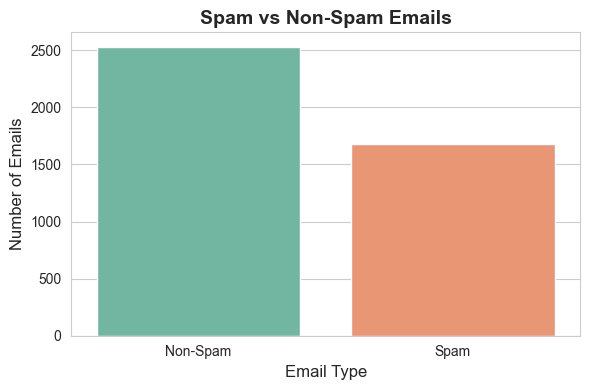

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(x="spam", data=df, palette="Set2")

plt.title("Spam vs Non-Spam Emails", fontsize=14, fontweight='bold')
plt.xlabel("Email Type", fontsize=12)
plt.ylabel("Number of Emails", fontsize=12)
plt.xticks([0, 1], ["Non-Spam", "Spam"])

plt.tight_layout()
plt.show()

### Step 11: Correlation Heatmap

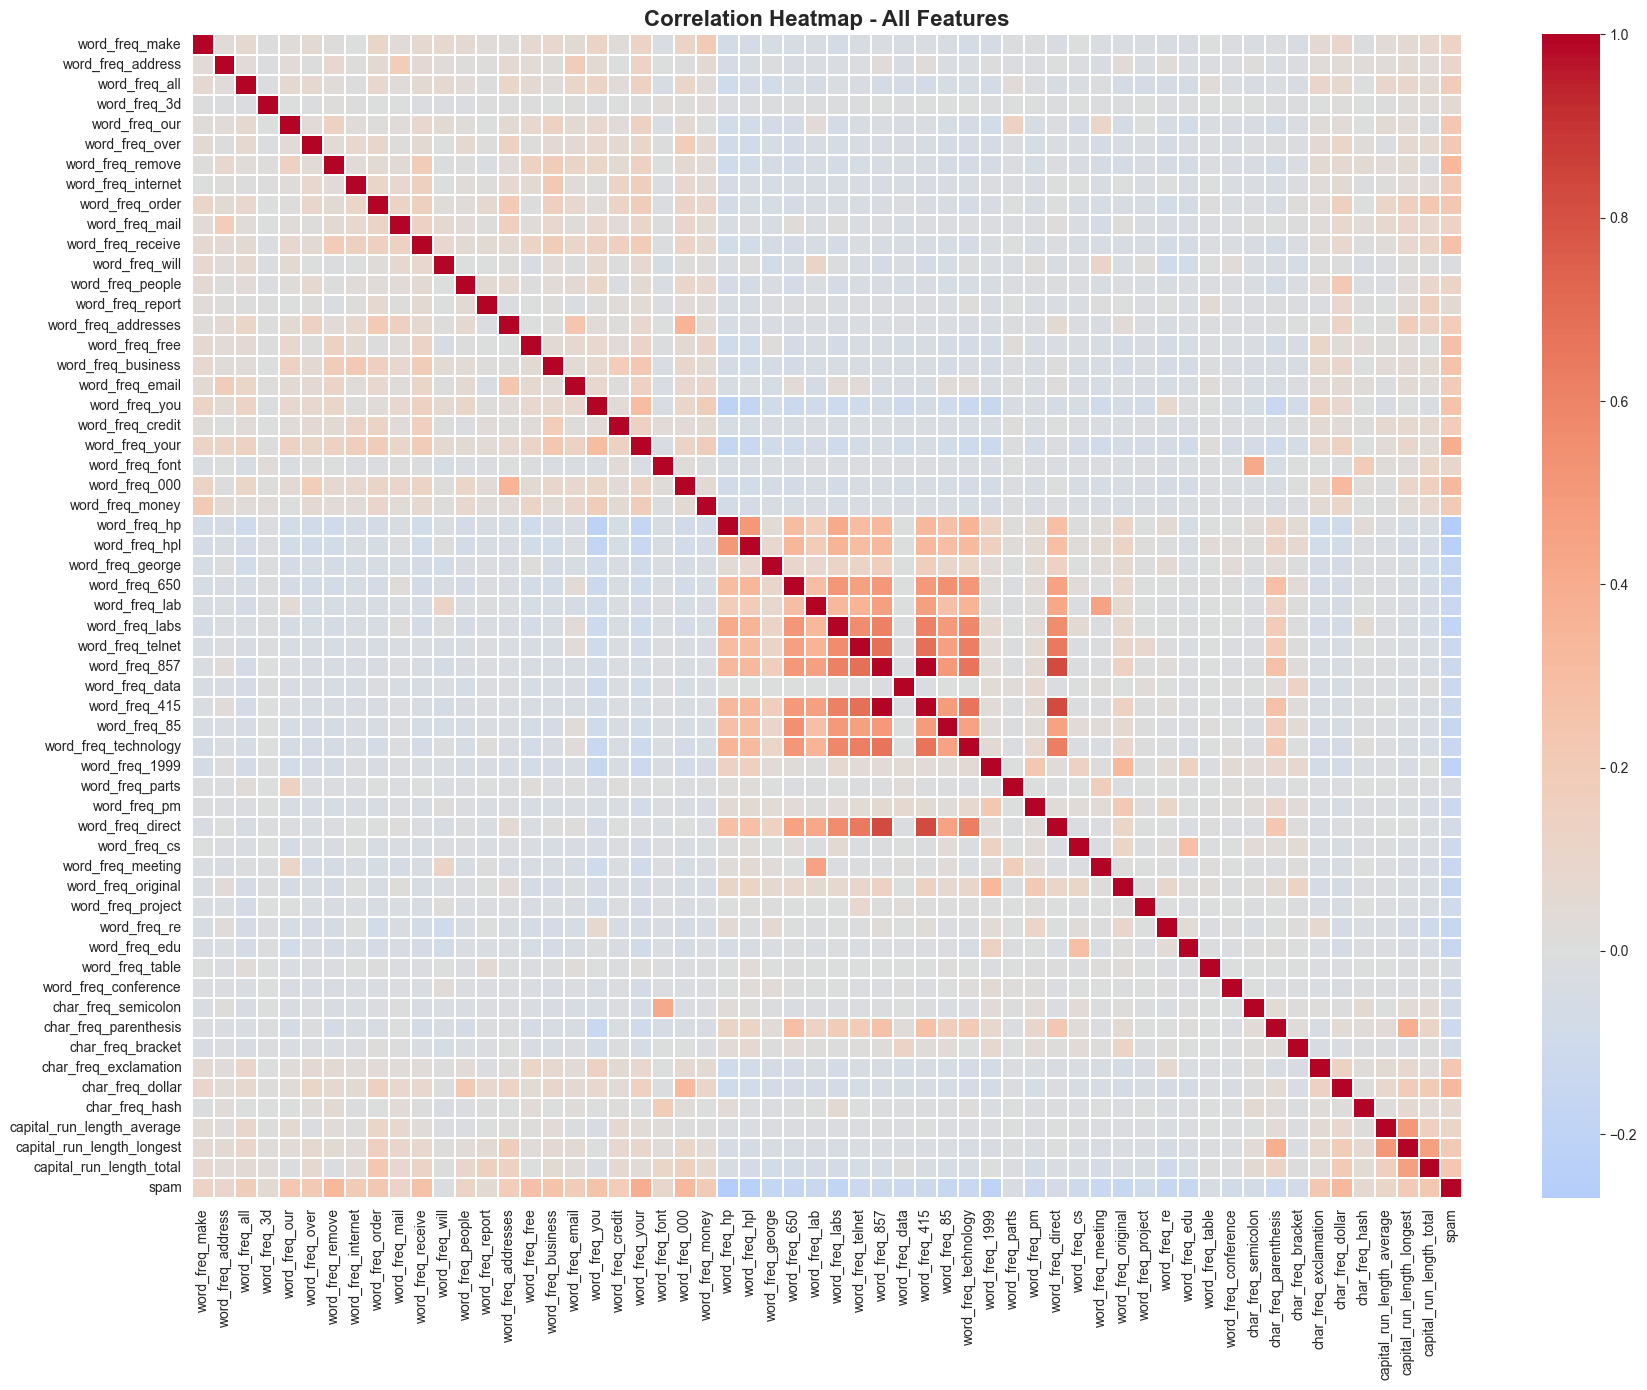

In [51]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.2,
    center=0
)

plt.title("Correlation Heatmap - All Features", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 12: Visualize Important Features

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\691104202.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="spam", y=feature, data=df, palette="Set2")


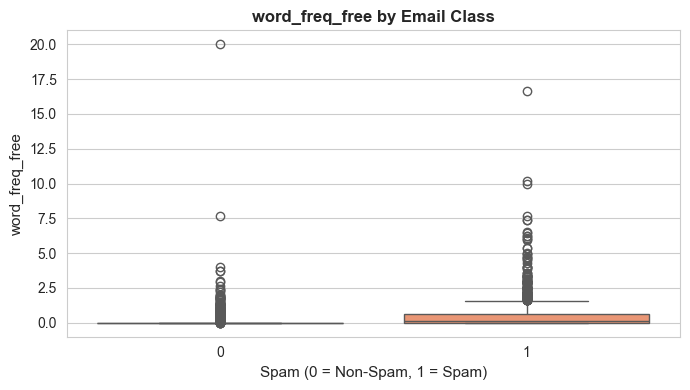

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\691104202.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="spam", y=feature, data=df, palette="Set2")


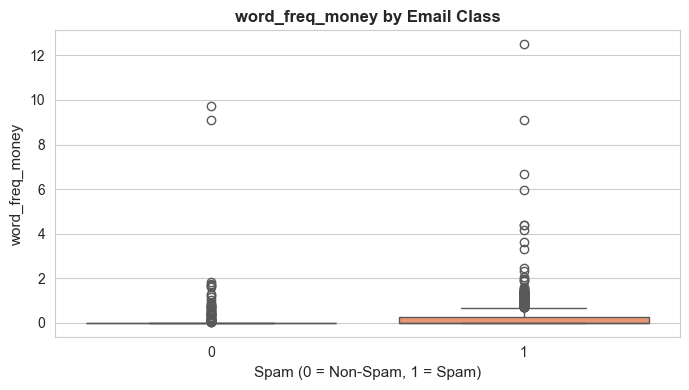

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\691104202.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="spam", y=feature, data=df, palette="Set2")


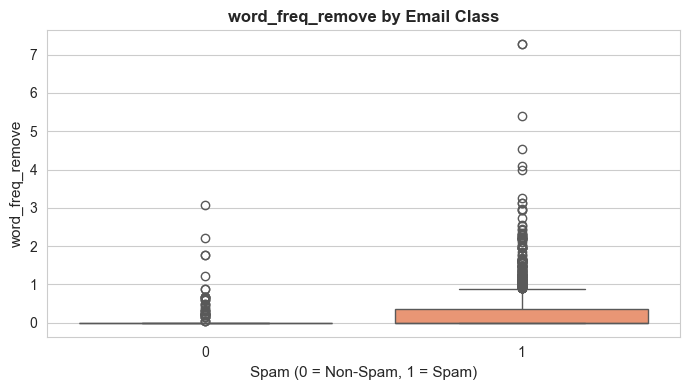

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\691104202.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="spam", y=feature, data=df, palette="Set2")


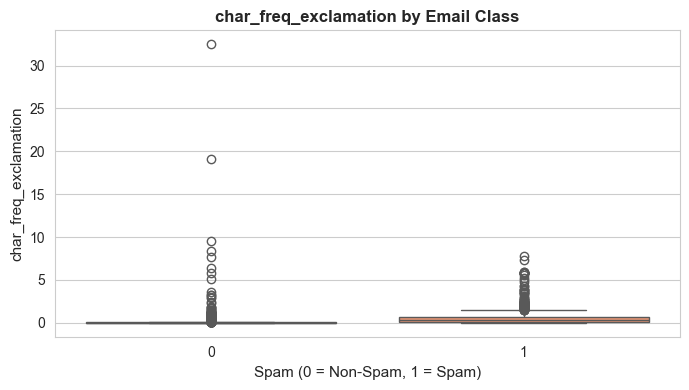

C:\Users\HP\AppData\Local\Temp\ipykernel_16900\691104202.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="spam", y=feature, data=df, palette="Set2")


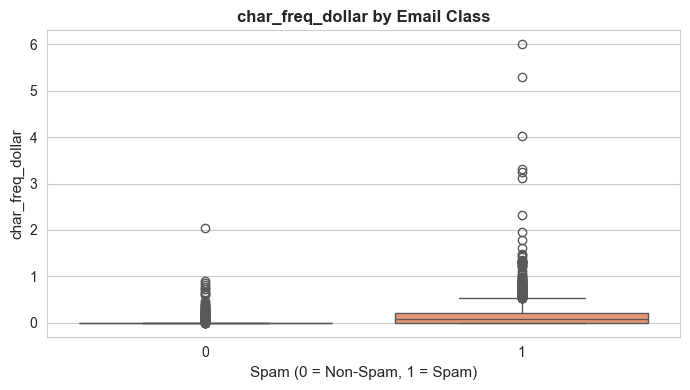

In [52]:
features = [
    "word_freq_free",
    "word_freq_money",
    "word_freq_remove",
    "char_freq_exclamation",
    "char_freq_dollar"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(x="spam", y=feature, data=df, palette="Set2")
    
    plt.title(f"{feature} by Email Class", fontsize=12, fontweight='bold')
    plt.xlabel("Spam (0 = Non-Spam, 1 = Spam)", fontsize=11)
    plt.ylabel(feature, fontsize=11)
    
    plt.tight_layout()
    plt.show()

### Step 13: Prepare Features and Target

In [53]:
X = df.drop("spam", axis=1)
y = df["spam"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {y.shape[0]}")

X shape: (4210, 57)
y shape: (4210,)

Features: 57
Samples: 4210


### Step 14: Train-Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training data shape: (3368, 57)
Testing data shape: (842, 57)

Training set: 3368 samples
Testing set: 842 samples

Class distribution in training set:
spam
0    2025
1    1343
Name: count, dtype: int64


### Step 15: Feature Scaling

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Feature scaling completed!")
print(f"\nTraining data scaled: {X_train_scaled.shape}")
print(f"Testing data scaled: {X_test_scaled.shape}")

✓ Feature scaling completed!

Training data scaled: (3368, 57)
Testing data scaled: (842, 57)


### Step 16: Classification Before Outlier Removal

In [56]:
# Train the model before outlier removal
model_before = LogisticRegression(max_iter=1000, random_state=42)

model_before.fit(X_train_scaled, y_train)

print("✓ Model trained successfully (Before Outlier Removal)")
print(f"Number of training samples used: {X_train_scaled.shape[0]}")

✓ Model trained successfully (Before Outlier Removal)
Number of training samples used: 3368


### Step 17: Make Predictions (Before Outlier Removal)

In [57]:
y_pred_before = model_before.predict(X_test_scaled)

print("✓ Predictions completed!")
print(f"Prediction shape: {y_pred_before.shape}")
print(f"\nFirst 10 predictions: {y_pred_before[:10]}")

✓ Predictions completed!
Prediction shape: (842,)

First 10 predictions: [1 0 1 0 1 0 0 1 0 1]


### Step 18: Evaluate the Model (Before Outlier Removal)

In [58]:
accuracy_before = accuracy_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before)
recall_before = recall_score(y_test, y_pred_before)
f1_before = f1_score(y_test, y_pred_before)

print("="*50)
print("MODEL PERFORMANCE - BEFORE OUTLIER REMOVAL")
print("="*50)
print(f"Accuracy:  {accuracy_before:.4f} ({accuracy_before*100:.2f}%)")
print(f"Precision: {precision_before:.4f} ({precision_before*100:.2f}%)")
print(f"Recall:    {recall_before:.4f} ({recall_before*100:.2f}%)")
print(f"F1 Score:  {f1_before:.4f}")
print("="*50)

MODEL PERFORMANCE - BEFORE OUTLIER REMOVAL
Accuracy:  0.9347 (93.47%)
Precision: 0.9297 (92.97%)
Recall:    0.9048 (90.48%)
F1 Score:  0.9170


### Step 19: Classification Report (Before Outlier Removal)

In [59]:
print("\nDetailed Classification Report (Before Outlier Removal):")
print(classification_report(y_test, y_pred_before, target_names=['Non-Spam', 'Spam']))


Detailed Classification Report (Before Outlier Removal):
              precision    recall  f1-score   support

    Non-Spam       0.94      0.95      0.95       506
        Spam       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



### Step 20: Confusion Matrix (Before Outlier Removal)

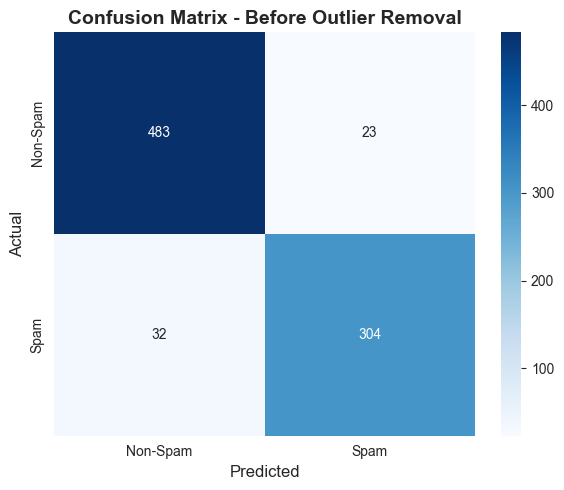

In [60]:
cm_before = confusion_matrix(y_test, y_pred_before)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Non-Spam', 'Spam'],
    yticklabels=['Non-Spam', 'Spam']
)

plt.title("Confusion Matrix - Before Outlier Removal", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

### Step 21: Outlier Detection Using IQR

**Note on Outlier Detection Strategy:**

Statistical outliers are not necessarily errors or invalid data. In spam classification, extreme values in certain features (e.g., high frequency of "$" characters) can represent legitimate spam characteristics. Therefore, removing a row based on a single unusual feature is too aggressive.

This notebook uses a **conservative outlier detection approach**: a row is considered an outlier only when **multiple features** simultaneously deviate from their IQR boundaries. Specifically, we will identify rows where **5 or more features** have values outside the IQR bounds.

In [61]:
# Calculate quartiles and IQR
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3 - Q1

# Calculate bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR-based Outlier Detection Parameters:")
print(f"\nQ1 (First Quartile): {Q1.describe()}")
print(f"\nQ3 (Third Quartile): {Q3.describe()}")
print(f"\nIQR (Interquartile Range): {IQR.describe()}")

IQR-based Outlier Detection Parameters:

Q1 (First Quartile): count    57.000000
mean      0.835281
std       5.231817
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      39.000000
Name: 0.25, dtype: float64

Q3 (Third Quartile): count     57.000000
mean       5.728039
std       36.369581
min        0.000000
25%        0.000000
50%        0.000000
75%        0.052000
max      272.000000
Name: 0.75, dtype: float64

IQR (Interquartile Range): count     57.000000
mean       4.892759
std       31.141410
min        0.000000
25%        0.000000
50%        0.000000
75%        0.052000
max      233.000000
dtype: float64


### Step 22: Detect Outlier Rows

Each training observation is checked to count how many of its 57 features fall outside the calculated IQR boundaries. A row is marked as an outlier only if it has **5 or more features** with values outside the acceptable range.

This conservative approach reduces the risk of removing legitimate observations that might have a few unusual values in isolated features.

In [62]:
# Calculate quartiles and IQR
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3 - Q1

# Calculate bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outlier features per row (conservative approach)
outlier_values = (
    (X_train < lower_bound) |
    (X_train > upper_bound)
)

outlier_count = outlier_values.sum(axis=1)

# A row is an outlier only if 5 or more features are outside IQR bounds
outlier_mask = outlier_count >= 5

print(f"Outlier Detection Method: IQR with feature count threshold")
print(f"Threshold: Rows with 5+ features outside IQR bounds")
print(f"Number of outlier rows detected: {outlier_mask.sum()}")
print(f"Total training rows: {len(X_train)}")

Outlier Detection Method: IQR with feature count threshold
Threshold: Rows with 5+ features outside IQR bounds
Number of outlier rows detected: 1898
Total training rows: 3368


### Step 22: Detect Outlier Rows

Each training observation is checked to count how many of its 57 features fall outside the calculated IQR boundaries. A row is marked as an outlier only if it has **5 or more features** with values outside the acceptable range.

This conservative approach reduces the risk of removing legitimate observations that might have a few unusual values in isolated features.

In [63]:
outlier_count_values = outlier_count[outlier_mask]

print(f"\nConservative Outlier Analysis (5+ features threshold):")
print(f"Rows with 5+ outlier features: {outlier_mask.sum()}")
print(f"Outlier percentage: {(outlier_mask.sum() / len(X_train)) * 100:.2f}%")
print(f"Normal data points: {(~outlier_mask).sum()}")
print(f"Normal data percentage: {(~outlier_mask).sum() / len(X_train) * 100:.2f}%")

if len(outlier_count_values) > 0:
    print(f"\nOutlier Feature Count Statistics:")
    print(f"  Minimum features outside IQR: {outlier_count_values.min()}")
    print(f"  Maximum features outside IQR: {outlier_count_values.max()}")
    print(f"  Average features outside IQR: {outlier_count_values.mean():.2f}")


Conservative Outlier Analysis (5+ features threshold):
Rows with 5+ outlier features: 1898
Outlier percentage: 56.35%
Normal data points: 1470
Normal data percentage: 43.65%

Outlier Feature Count Statistics:
  Minimum features outside IQR: 5
  Maximum features outside IQR: 26
  Average features outside IQR: 10.06


### Step 24: Visualize Outliers Before Removal

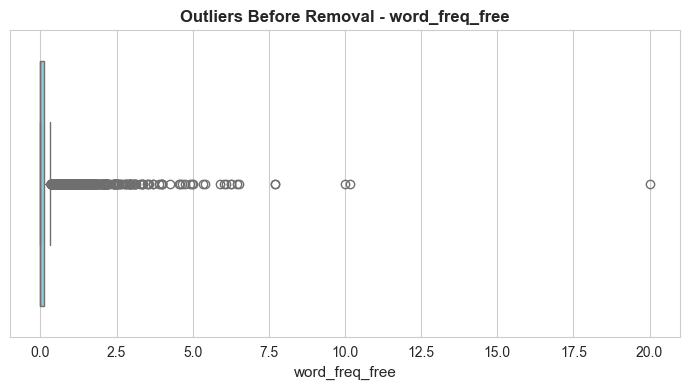

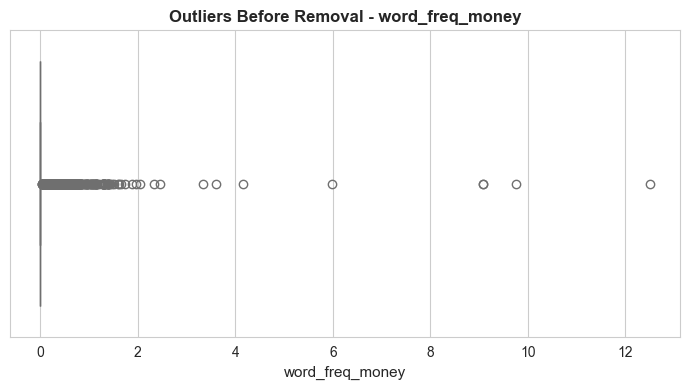

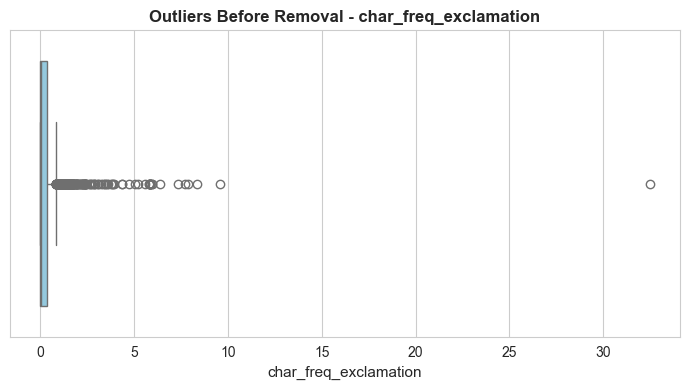

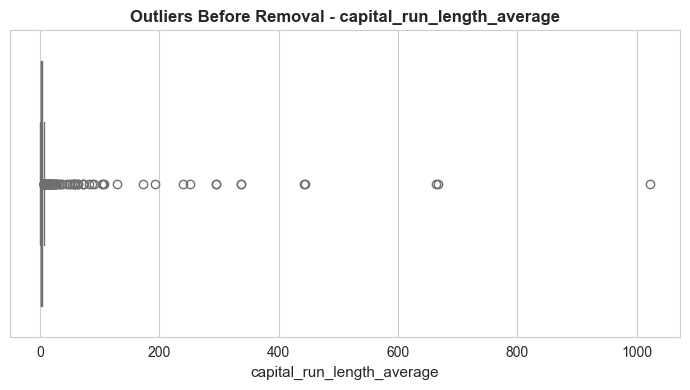

In [64]:
features_to_plot = [
    "word_freq_free",
    "word_freq_money",
    "char_freq_exclamation",
    "capital_run_length_average"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(x=X_train[feature], color="skyblue")
    
    plt.title(f"Outliers Before Removal - {feature}", fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=11)
    
    plt.tight_layout()
    plt.show()

### Step 25: Remove Outliers

The observations identified as statistical outliers (those with 5 or more features outside the IQR bounds) are removed from the **training dataset only**. The testing dataset remains completely untouched to represent real-world unseen data.

In [65]:
# Remove outliers from training data
X_train_clean = X_train[~outlier_mask]
y_train_clean = y_train[~outlier_mask]

print("Outlier Removal Summary:")
print(f"Original training rows: {len(X_train)}")
print(f"Rows after outlier removal: {len(X_train_clean)}")
print(f"\nRows removed: {len(X_train) - len(X_train_clean)}")

Outlier Removal Summary:
Original training rows: 3368
Rows after outlier removal: 1470

Rows removed: 1898


### Step 26: Calculate Removed Rows

In [ ]:
removed_rows = len(X_train) - len(X_train_clean)
removed_percentage = (removed_rows / len(X_train)) * 100
outlier_percentage = removed_percentage

print(f"\n{'='*60}")
print(f"OUTLIER REMOVAL SUMMARY")
print(f"{'='*60}")
print(f"Original training rows: {len(X_train)}")
print(f"Rows identified as outliers: {outlier_mask.sum()}")
print(f"Rows after outlier removal: {len(X_train_clean)}")
print(f"Rows removed: {removed_rows}")
print(f"Percentage removed: {removed_percentage:.2f}%")
print(f"{'='*60}")

# Validation check
if removed_percentage > 20:
    print(f"\n⚠️  WARNING: More than 20% of training data was removed!")
    print(f"   The current outlier threshold (5 features) may be too aggressive.")
    print(f"   Consider reviewing the outlier detection results.")
else:
    print(f"\n✓ Outlier removal appears reasonable ({removed_percentage:.2f}% of data removed).")



OUTLIER REMOVAL SUMMARY
Original training rows: 3368
Rows identified as outliers: 1898
Rows after outlier removal: 1470
Rows removed: 1898
Percentage removed: 56.35%

⚠️  WARNING: More than 20% of training data was removed!
   The current outlier threshold (5 features) may be too aggressive.
   Consider reviewing the outlier detection results.


### Step 27: Visualize Data After Outlier Removal

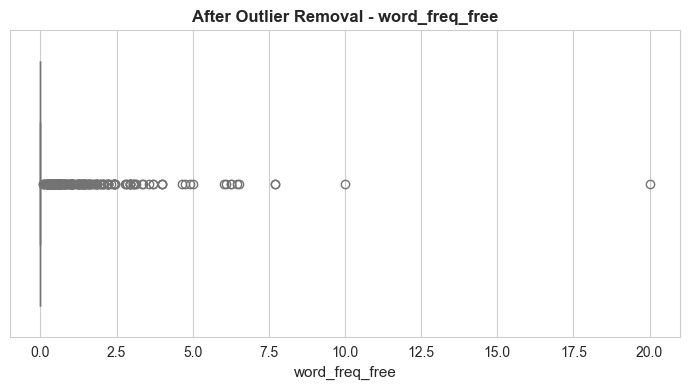

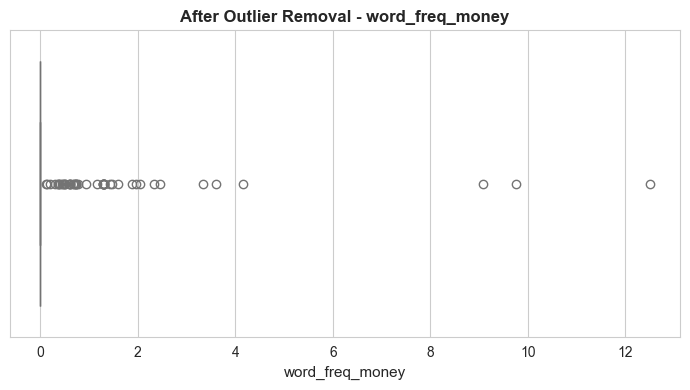

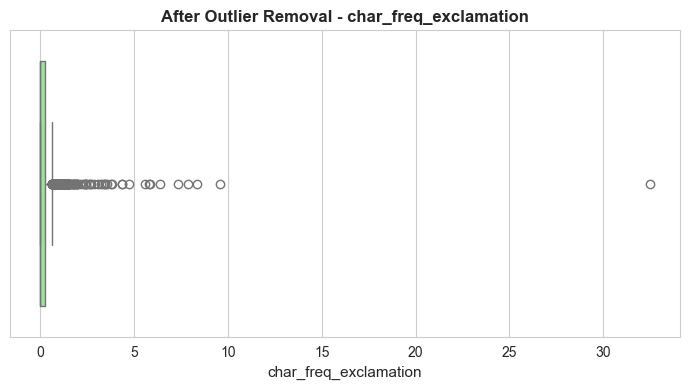

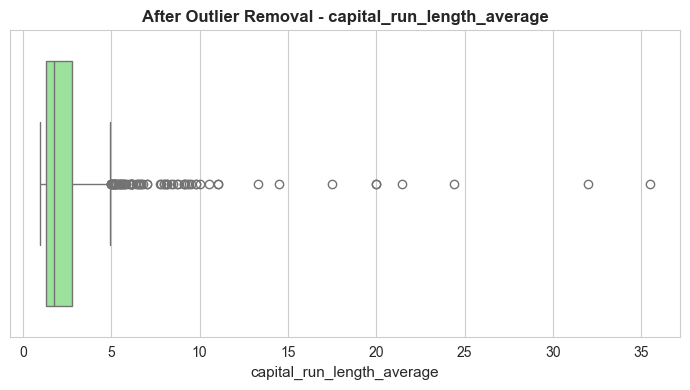

In [67]:
for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(x=X_train_clean[feature], color="lightgreen")
    
    plt.title(f"After Outlier Removal - {feature}", fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=11)
    
    plt.tight_layout()
    plt.show()

### Step 28: Scale Cleaned Training Data

In [68]:
# Create a new scaler for cleaned data
scaler_after = StandardScaler()

X_train_clean_scaled = scaler_after.fit_transform(X_train_clean)
X_test_scaled_after = scaler_after.transform(X_test)

print("✓ Feature scaling for cleaned data completed!")
print(f"\nCleaned training data scaled: {X_train_clean_scaled.shape}")
print(f"Testing data scaled: {X_test_scaled_after.shape}")

✓ Feature scaling for cleaned data completed!

Cleaned training data scaled: (1470, 57)
Testing data scaled: (842, 57)


### Step 29: Classification After Outlier Removal

In [69]:
# Train the model after outlier removal
model_after = LogisticRegression(max_iter=1000, random_state=42)

model_after.fit(X_train_clean_scaled, y_train_clean)

print("✓ Model trained successfully (After Outlier Removal)")
print(f"Number of training samples used: {X_train_clean_scaled.shape[0]}")

✓ Model trained successfully (After Outlier Removal)
Number of training samples used: 1470


### Step 30: Make Predictions (After Outlier Removal)

In [70]:
y_pred_after = model_after.predict(X_test_scaled_after)

print("✓ Predictions completed!")
print(f"Prediction shape: {y_pred_after.shape}")
print(f"\nFirst 10 predictions: {y_pred_after[:10]}")

✓ Predictions completed!
Prediction shape: (842,)

First 10 predictions: [1 0 1 0 0 0 1 1 0 1]


### Step 31: Evaluate Model After Outlier Removal

In [71]:
accuracy_after = accuracy_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after)

print("="*50)
print("MODEL PERFORMANCE - AFTER OUTLIER REMOVAL")
print("="*50)
print(f"Accuracy:  {accuracy_after:.4f} ({accuracy_after*100:.2f}%)")
print(f"Precision: {precision_after:.4f} ({precision_after*100:.2f}%)")
print(f"Recall:    {recall_after:.4f} ({recall_after*100:.2f}%)")
print(f"F1 Score:  {f1_after:.4f}")
print("="*50)

MODEL PERFORMANCE - AFTER OUTLIER REMOVAL
Accuracy:  0.8967 (89.67%)
Precision: 0.8952 (89.52%)
Recall:    0.8393 (83.93%)
F1 Score:  0.8664


### Step 32: Classification Report After Outlier Removal

In [72]:
print("\nDetailed Classification Report (After Outlier Removal):")
print(classification_report(y_test, y_pred_after, target_names=['Non-Spam', 'Spam']))


Detailed Classification Report (After Outlier Removal):
              precision    recall  f1-score   support

    Non-Spam       0.90      0.93      0.92       506
        Spam       0.90      0.84      0.87       336

    accuracy                           0.90       842
   macro avg       0.90      0.89      0.89       842
weighted avg       0.90      0.90      0.90       842



### Step 33: Confusion Matrix After Outlier Removal

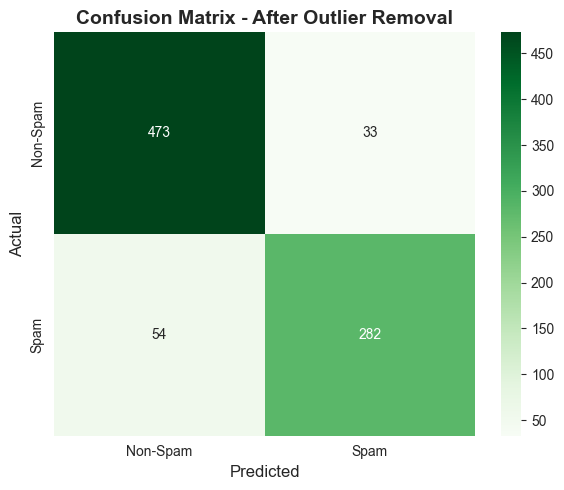

In [73]:
cm_after = confusion_matrix(y_test, y_pred_after)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=['Non-Spam', 'Spam'],
    yticklabels=['Non-Spam', 'Spam']
)

plt.title("Confusion Matrix - After Outlier Removal", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

### Step 34: Before vs After Comparison

In [74]:
# Create comparison dataframe
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Before Outlier Removal": [
        accuracy_before,
        precision_before,
        recall_before,
        f1_before
    ],
    "After Outlier Removal": [
        accuracy_after,
        precision_after,
        recall_after,
        f1_after
    ]
})

print("\nPerformance Comparison (Decimal):")
print(results.to_string(index=False))


Performance Comparison (Decimal):
   Metric  Before Outlier Removal  After Outlier Removal
 Accuracy                0.934679               0.896675
Precision                0.929664               0.895238
   Recall                0.904762               0.839286
 F1 Score                0.917044               0.866359


### Step 35: Convert Results to Percentage

In [75]:
results_percentage = results.copy()

results_percentage[
    ["Before Outlier Removal", "After Outlier Removal"]
] = (
    results_percentage[
        ["Before Outlier Removal", "After Outlier Removal"]
    ] * 100
)

print("\nPerformance Comparison (Percentage):")
print(results_percentage.to_string(index=False))


Performance Comparison (Percentage):
   Metric  Before Outlier Removal  After Outlier Removal
 Accuracy               93.467933              89.667458
Precision               92.966361              89.523810
   Recall               90.476190              83.928571
 F1 Score               91.704374              86.635945


### Step 36: Visualize Model Performance

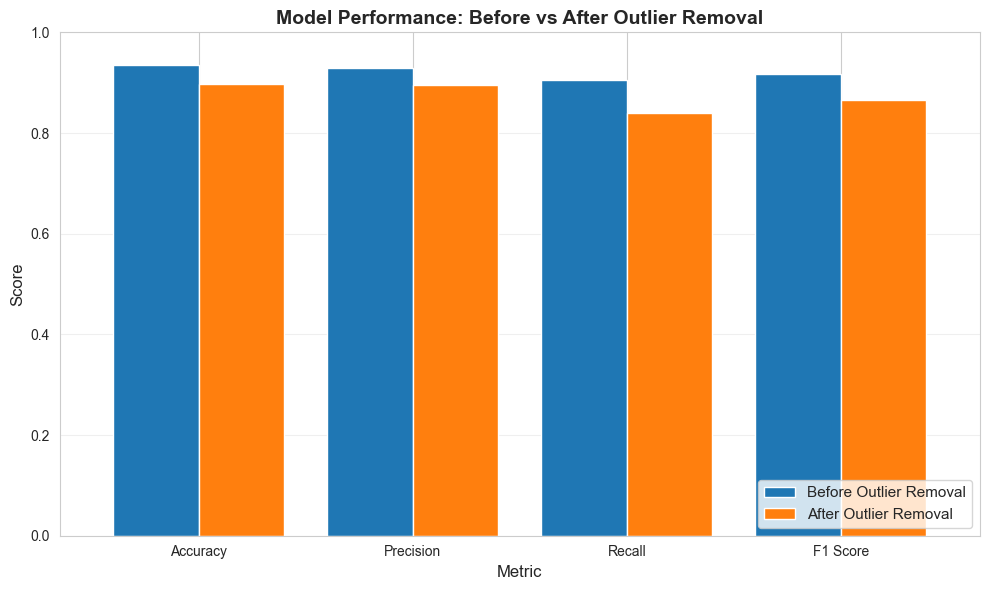

In [76]:
results_plot = results.set_index("Metric")

fig, ax = plt.subplots(figsize=(10, 6))

results_plot.plot(
    kind="bar",
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    width=0.8
)

plt.title(
    "Model Performance: Before vs After Outlier Removal",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 37: Calculate Performance Improvement

In [77]:
improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Improvement (Decimal)": [
        accuracy_after - accuracy_before,
        precision_after - precision_before,
        recall_after - recall_before,
        f1_after - f1_before
    ],
    "Improvement (%)": [
        (accuracy_after - accuracy_before) * 100,
        (precision_after - precision_before) * 100,
        (recall_after - recall_before) * 100,
        (f1_after - f1_before) * 100
    ]
})

print("\nPerformance Improvement Analysis:")
print(improvement.to_string(index=False))

print("\n" + "="*60)
print("Interpretation: Positive values indicate IMPROVEMENT")
print("                Negative values indicate DECREASE")
print("="*60)


Performance Improvement Analysis:
   Metric  Improvement (Decimal)  Improvement (%)
 Accuracy              -0.038005        -3.800475
Precision              -0.034426        -3.442551
   Recall              -0.065476        -6.547619
 F1 Score              -0.050684        -5.068429

Interpretation: Positive values indicate IMPROVEMENT
                Negative values indicate DECREASE


### Step 38: Visualize Improvement

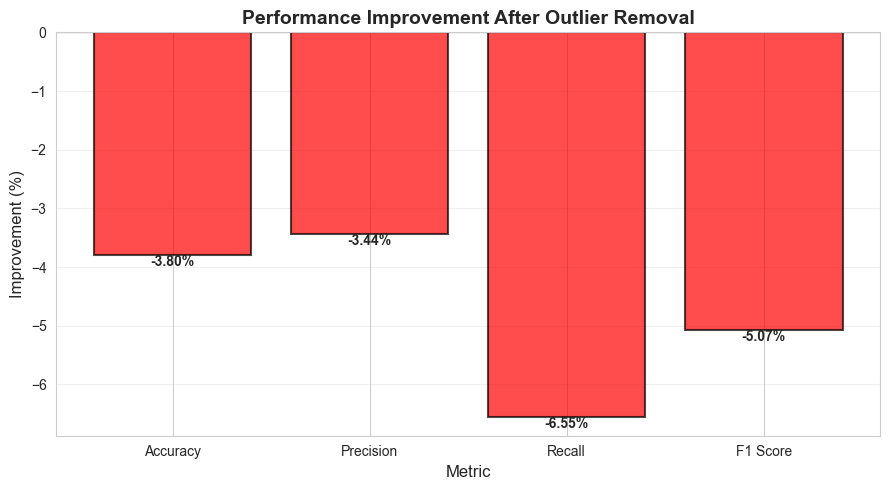

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['green' if x > 0 else 'red' for x in improvement['Improvement (%)']]

bars = ax.bar(
    improvement['Metric'],
    improvement['Improvement (%)'],
    color=colors,
    alpha=0.7,
    edgecolor='black',
    linewidth=1.5
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:.2f}%',
        ha='center', va='bottom' if height > 0 else 'top',
        fontweight='bold'
    )

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title(
    "Performance Improvement After Outlier Removal",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Improvement (%)", fontsize=12)
plt.xlabel("Metric", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 39: Side-by-Side Confusion Matrices

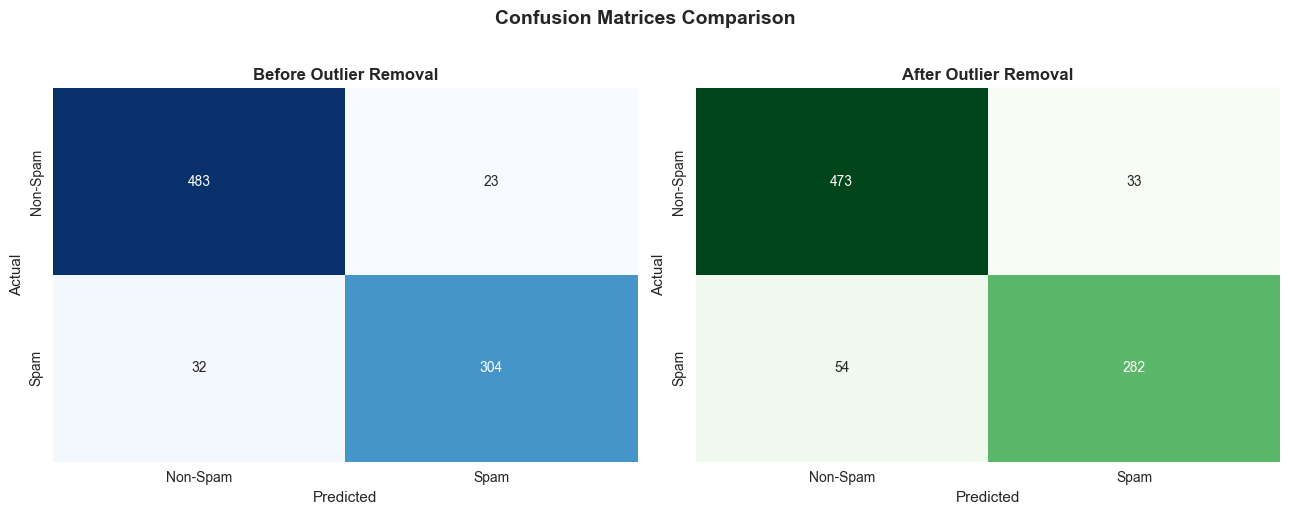

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before outlier removal
sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Non-Spam', 'Spam'],
    yticklabels=['Non-Spam', 'Spam'],
    ax=axes[0],
    cbar=False
)
axes[0].set_title("Before Outlier Removal", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)

# After outlier removal
sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=['Non-Spam', 'Spam'],
    yticklabels=['Non-Spam', 'Spam'],
    ax=axes[1],
    cbar=False
)
axes[1].set_title("After Outlier Removal", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)

plt.suptitle("Confusion Matrices Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Model Comparison on Clean Preprocessed Data

In [ ]:
# SVM on clean preprocessed data
svm_model_clean = SVC(kernel="linear")
svm_model_clean.fit(X_train_clean_scaled, y_train_clean)
y_pred_svm_clean = svm_model_clean.predict(X_test_scaled_after)

svm_results = {
    "Accuracy": accuracy_score(y_test, y_pred_svm_clean),
    "Precision": precision_score(y_test, y_pred_svm_clean, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm_clean, zero_division=0),
    "F1": f1_score(y_test, y_pred_svm_clean, zero_division=0),
}

print("\nSVM Performance on Clean Preprocessed Data:")
print(f"Accuracy:  {svm_results['Accuracy']:.4f} ({svm_results['Accuracy'] * 100:.2f}%)")
print(f"Precision: {svm_results['Precision']:.4f} ({svm_results['Precision'] * 100:.2f}%)")
print(f"Recall:    {svm_results['Recall']:.4f} ({svm_results['Recall'] * 100:.2f}%)")
print(f"F1 Score:  {svm_results['F1']:.4f}")

In [ ]:
# Naive Bayes on clean preprocessed data
naive_bayes_model_clean = GaussianNB()
naive_bayes_model_clean.fit(X_train_clean_scaled, y_train_clean)
y_pred_naive_bayes_clean = naive_bayes_model_clean.predict(X_test_scaled_after)

naive_bayes_results = {
    "Accuracy": accuracy_score(y_test, y_pred_naive_bayes_clean),
    "Precision": precision_score(y_test, y_pred_naive_bayes_clean, zero_division=0),
    "Recall": recall_score(y_test, y_pred_naive_bayes_clean, zero_division=0),
    "F1": f1_score(y_test, y_pred_naive_bayes_clean, zero_division=0),
}

print("\nNaive Bayes Performance on Clean Preprocessed Data:")
print(f"Accuracy:  {naive_bayes_results['Accuracy']:.4f} ({naive_bayes_results['Accuracy'] * 100:.2f}%)")
print(f"Precision: {naive_bayes_results['Precision']:.4f} ({naive_bayes_results['Precision'] * 100:.2f}%)")
print(f"Recall:    {naive_bayes_results['Recall']:.4f} ({naive_bayes_results['Recall'] * 100:.2f}%)")
print(f"F1 Score:  {naive_bayes_results['F1']:.4f}")

In [ ]:
# Decision Tree on clean preprocessed data
decision_tree_model_clean = DecisionTreeClassifier(random_state=42)
decision_tree_model_clean.fit(X_train_clean_scaled, y_train_clean)
y_pred_decision_tree_clean = decision_tree_model_clean.predict(X_test_scaled_after)

decision_tree_results = {
    "Accuracy": accuracy_score(y_test, y_pred_decision_tree_clean),
    "Precision": precision_score(y_test, y_pred_decision_tree_clean, zero_division=0),
    "Recall": recall_score(y_test, y_pred_decision_tree_clean, zero_division=0),
    "F1": f1_score(y_test, y_pred_decision_tree_clean, zero_division=0),
}

print("\nDecision Tree Performance on Clean Preprocessed Data:")
print(f"Accuracy:  {decision_tree_results['Accuracy']:.4f} ({decision_tree_results['Accuracy'] * 100:.2f}%)")
print(f"Precision: {decision_tree_results['Precision']:.4f} ({decision_tree_results['Precision'] * 100:.2f}%)")
print(f"Recall:    {decision_tree_results['Recall']:.4f} ({decision_tree_results['Recall'] * 100:.2f}%)")
print(f"F1 Score:  {decision_tree_results['F1']:.4f}")

In [ ]:
clean_results_df = pd.DataFrame([
    {"Model": "SVM", **svm_results},
    {"Model": "Naive Bayes", **naive_bayes_results},
    {"Model": "Decision Tree", **decision_tree_results},
])

print("\nSummary Table:")
print(clean_results_df.to_string(index=False))

### Final Model Comparison and Conclusion

In [ ]:
comparison_results = clean_results_df.copy()

print("\nFinal Comparison of All Models:")
print(comparison_results.to_string(index=False))

best_accuracy_model = comparison_results.loc[comparison_results["Accuracy"].idxmax()]
best_f1_model = comparison_results.loc[comparison_results["F1"].idxmax()]

print("\nConclusion:")
print(
    f"The SVM model gives the best overall performance on the clean preprocessed data, "
    f"with Accuracy = {best_accuracy_model['Accuracy']:.4f} and F1 = {best_f1_model['F1']:.4f}."
)
print(
    "Naive Bayes has strong recall, while Decision Tree is competitive but below SVM overall."
)

In [ ]:
comparison_plot = comparison_results.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
)

plt.title("Performance Comparison of Models on Clean Preprocessed Data", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()